### Задание 2
В коде ниже — наивная реализация позиционной кодировки RoPE. Допишите недостающие части, чтобы реализовать интерполяцию на возрастающий размер контекста с помощью метода YaRN. 

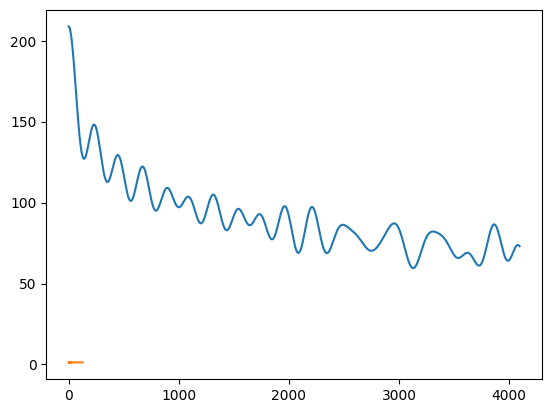

In [1]:
import torch
from typing import Optional
from matplotlib import pyplot as plt
import math

def apply_rope(
    x: torch.tensor,
    base: Optional[int],
    orig_seq_len: Optional[int],
    extended_seq_len: Optional[int],
    beta: int = 32,
    alpha: int = 1
  ):

    batch_size, num_heads, seq_len, head_dim = x.shape
    
    # дефолтный температурный коэффициент масштабирования sqrt(1/t)
    # изменяется в методе YaRN
    attn_factor = 1

    # частоты
    b = base ** (torch.arange(0, head_dim, 2).float() / head_dim)
    # обратные частоты
    inv_freqs = 1.0 / b

    if extended_seq_len:
      assert extended_seq_len > orig_seqlen

      # коэффициент масштабирования
      scale_factor = extended_seq_len / orig_seqlen
      # NTK-aware поправка b
      b_corrected = b * scale_factor ** (head_dim / (head_dim - 2) )
      # длина волны
      lambda_ = 2 * math.pi * b_corrected
      # относительный коэффициент r
      r = orig_seq_len / lambda_

      # NTK-by-parts диапазоны
      low_freq_mask = r < alpha
      high_freq_mask = r > beta

      # корректировочный коэффициент частот NTK-by-parts
      gamma = (r - alpha) / (alpha - beta)
      gamma[low_freq_mask] = 0
      gamma[high_freq_mask] = 1

      # пересчёт поправленных частот
      inv_freqs = (1-gamma)*inv_freqs/scale_factor + gamma*inv_freqs

      # корректировка температурного коэффициента масштабирования sqrt(1/t)
      attn_factor = 0.1 * math.log(scale_factor) + 1
      

    # Позиционные индексы
    positions = torch.arange(seq_len).float()

    # Решейп для дальнейших вычислений
    inv_freqs = inv_freqs.view(1, 1, 1, head_dim // 2)
    positions = positions.view(1, 1, seq_len, 1)

    # Вычисляем углы
    theta = positions * inv_freqs
    cos_theta = torch.cos(theta)
    sin_theta = torch.sin(theta)

    # Разделяем на пары для вращения
    x_reshaped = x.view(batch_size, num_heads, seq_len, head_dim // 2, 2)
    x1 = x_reshaped[..., 0]
    x2 = x_reshaped[..., 1]

    # Применяем вращение
    x1_rot = x1 * cos_theta - x2 * sin_theta
    x2_rot = x1 * sin_theta + x2 * cos_theta

    # Собираем обратно
    x_rot = torch.stack([x1_rot, x2_rot], dim=-1)
    x_rot = x_rot.view(batch_size, num_heads, seq_len, head_dim)

    # Учитываем температурный коэффициент масштабирования
    x_rot = x_rot * attn_factor

    return x_rot

# Попробуем применить
#===============================================

# RoPE params
base = 10_000
orig_seqlen = 256
extanded_seqlen = 4096
# extanded_seqlen = None

# Input and attention params
batch_size = 2
num_heads = 16
head_dim = 128

seq_len = extanded_seqlen or orig_seqlen

x = torch.ones((batch_size, num_heads, seq_len, head_dim))
x_roped = apply_rope(
            x,
            base,
            orig_seqlen,
            extanded_seqlen,
          )
#===============================================

# Визуализация результатов
#===============================================
# Зависимость произведения x_0*x_j в зависимости от позиции j
plt.plot(torch.matmul(x_roped, x_roped.transpose(-1, -2)).mean((0,1))[0])
#===============================================
# Убывание частоты RoPE вдоль размерности скрытого состояния
plt.plot(x_roped[0][0][2])